# CIFAR Image Generator on Google Colab

This notebook allows you to train and test the **CIFAR Image Generator** on Google Colab's infrastructure (GPU recommended).

### Check GPU Availability

In [2]:
!nvidia-smi

Tue Feb 17 03:51:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   35C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Setting Up the Workspace

In [4]:
# 2. Mount Drive and Setup Repository
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define paths
drive_path = "/content/drive/MyDrive/" # You can change this path
user = "Bhavikupadhyay"
repo = "cifar-image-generator"
repo_full_path = os.path.join(drive_path, repo)

# Create the base directory if it doesn't exist
if not os.path.exists(drive_path):
    os.makedirs(drive_path)

# Navigate to Drive path
%cd {drive_path}

if not os.path.exists(repo):
    print(f"Cloning {repo} into Drive for the first time...")
    # NOTE: If the repo is PRIVATE, you must use a token:
    # !git clone https://YOUR_TOKEN_HERE@github.com/{user}/{repo}.git
    !git clone https://github.com/{user}/{repo}.git
else:
    print(f"Repository already exists at {repo_full_path}. Pulling latest changes...")
    %cd {repo}
    !git pull

# Ensure we are inside the repo directory
%cd {repo_full_path}

Mounted at /content/drive
/content/drive/MyDrive
Repository already exists at /content/drive/MyDrive/cifar-image-generator. Pulling latest changes...
/content/drive/MyDrive/cifar-image-generator
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 48 (delta 13), reused 41 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (48/48), 1.71 MiB | 708.00 KiB/s, done.
From https://github.com/Bhavikupadhyay/cifar-image-generator
   4c7843f..e087947  main       -> origin/main
 * [new branch]      dev-tools  -> origin/dev-tools
Updating 4c7843f..e087947
Fast-forward
 README.md                     |  53 +++---
 assets/generated_samples.png  | Bin 0 -> 168630 bytes
 assets/real_samples.png       | Bin 0 -> 156536 bytes
 assets/training_evolution.gif | Bin 0 -> 264505 bytes
 src/calculate_fid.py          |  94 ++++++++++
 train_and_sample_colab.ipynb  | 401 ++++++++++++++++++++++++++++++++++++++++-

### Install Dependencies

In [5]:
# For Colab, only need to install wandb. 
%pip install wandb
%pip install torchmetrics[image]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 56.3 MB/s eta 0:00:00


### Run the training loop

In [ ]:
from src import Config
from train import train
import torch

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

cfg = Config(
    use_wandb=True,
    use_amp=True,          # FP16 training — ~1.5-2x faster on Ampere/L4
    use_ema=True,          # EMA weights saved alongside main weights
    fid_every_epochs=25,   # compute FID every 25 epochs (0 = disabled)
    fid_num_samples=128,   # small sample count keeps each eval ~1 min
)

print("Starting training on Colab...")
print("="*30, "\n")
train(cfg)

### Inference

In [6]:
timestamp = '2026-02-16_07-27-22' # obtain from the above cell

In [7]:
!python inference.py --run_name {timestamp} --num_samples 64 --device cuda

Loaded config from: /content/drive/MyDrive/cifar-image-generator/runs/2026-02-16_07-27-22
Device: cuda
Loading latest checkpoint: ckpt_epoch_100.pth
Generating 64 samples...
Sampling : 100% 1000/1000 [00:56<00:00, 17.85it/s]
Saved sample grid to: /content/drive/MyDrive/cifar-image-generator/runs/2026-02-16_07-27-22/inference/inference_sample.png


### Visualize the Results

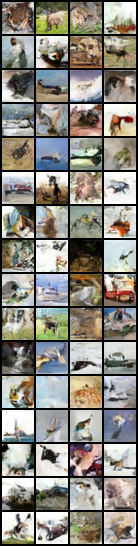

In [8]:
import os
from IPython.display import Image, display

img_path = f'runs/{timestamp}/inference/inference_sample.png'
if os.path.exists(img_path):
    display(Image(filename=img_path))
else:
    print("Image not found. Check if inference ran successfully.")

In [13]:
# Calculate FID Score for the current run
!PYTHONPATH=. python src/calculate_fid.py {timestamp} --num_samples 1000

Resuming run from: /content/drive/MyDrive/cifar-image-generator/runs/2026-02-16_07-27-22
Loading checkpoint: /content/drive/MyDrive/cifar-image-generator/runs/2026-02-16_07-27-22/ckpt/ckpt_epoch_100.pth
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100% 91.2M/91.2M [00:02<00:00, 33.5MB/s]
Generating 1000 fake images...
Sampling : 100% 1000/1000 [00:55<00:00, 18.08it/s]
Sampling : 100% 1000/1000 [00:56<00:00, 17.83it/s]
Sampling : 100% 1000/1000 [00:56<00:00, 17.56it/s]
Sampling : 100% 1000/1000 [00:57<00:00, 17.44it/s]
Sampling : 100% 1000/1000 [00:57<00:00, 17.24it/s]
Sampling : 100% 1000/1000 [00:58<00:00, 17.23it/s]
Sampling : 100% 1000/1000 [00:59<00:00, 16.86it/s]
Sampling : 100% 1000/1000 [00:59<00:00, 16.85it/s]
Sampling : 100% 1000/1000 [00:59<00:00, 16.79it/s]
Sampling : 100% 1000/1000 [00:58<00:00, 17.09it/s]
Sampling : 1